### Principal Stress Transformations

principals_geotechTools.ipynb - Copyright 2024 S.M.Arndt, Cavroc Pty Ltd
Visit **https://cavroc.com/** for more information on **IUCM** and **StopeX**

This file is part of [geotechTools](https://github.com/SMArndt/geotechTools). geotechTools is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation. geotechTools is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details. You should have received a copy of the GNU General Public License along with geotechTools. If not, see https://www.gnu.org/licenses/.

In [1]:
# ---------------------------------------------------------------------------
# imports
# ---------------------------------------------------------------------------

from xyzData import *
from gridData import *
from plot3D import *
from stressUtils import *

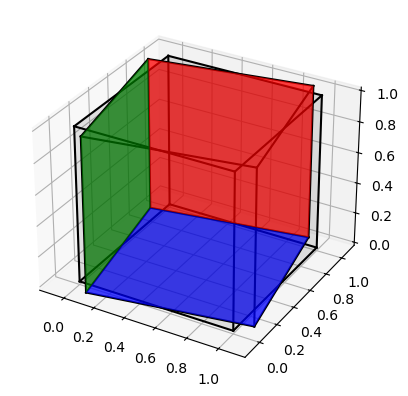

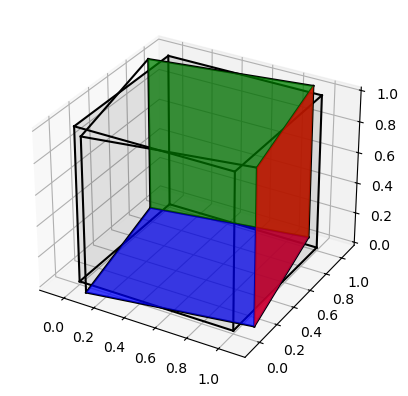

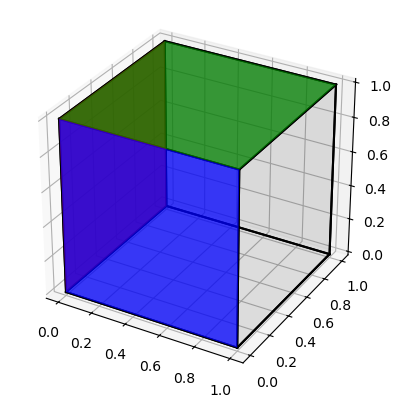

In [2]:
# ---------------------------------------------------------------------------
# example: convert principal stress to cartesian and back, plot as cube in 3D
# ---------------------------------------------------------------------------

# StopeX interface: input complex stress as gradient in MPa/m, positive values
# Using SI units in Abaqus [Pa, kg, m] compressive stress is negative
# Principals is a list of 3 principal stresses [[S_n, plunge_n, trend_n]]

Principals = [[-0.0493, 0., 80.], [-0.0295, 0., 170.], [-0.0265, 90., 0.]]

S=getCartesianStress(Principals)

E=getPrincipalStress(S)

for orientation in range(3):
    plot3DCube(Principals[orientation][1],Principals[orientation][2])

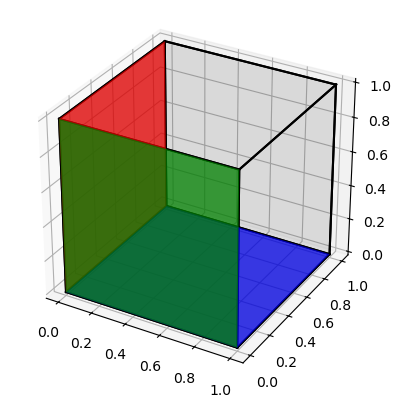

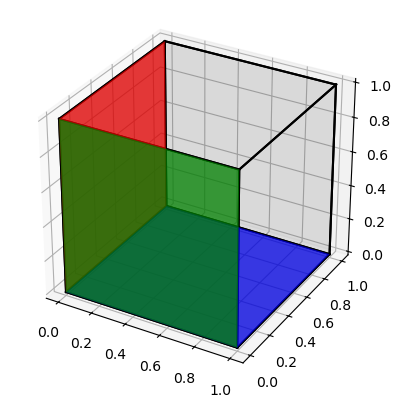

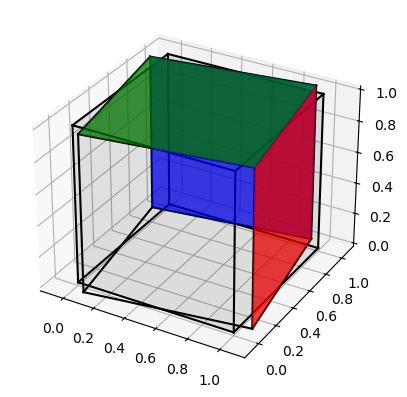

In [3]:
P=getStressOrientation(E[1]) # E[1] is the eigenvector matrix

for dip,trend in P:
    plot3DCube(dip,trend)

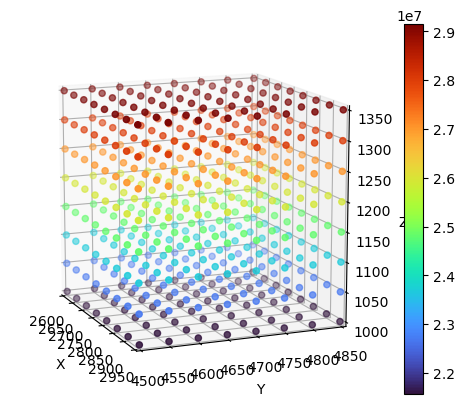

In [4]:
# ---------------------------------------------------------------------------
# Update on the extractStress() example from 'Don't Stress' using new methods
# ---------------------------------------------------------------------------

# read x,y,z data with stress columns
x = xyzData(r'regular_stress.csv')

# extract stress components using the new method extractStress()
stress=x.extractStress(indices='xyz')

# perform eigenvalue analysis
eigens=[]
for s_vec in stress:
    T=unpackStress(s_vec)                # new method unpackStress()
    e_val, e_vec = getPrincipalStress(T) # new method getPrincipalStress()
    eigens.append(e_val[0])              # S1

orientations=getStressOrientation(e_vec) # new method getStressOrientation()

# quick way to plot S1 (in last column, t.shape[1]-1)
t=np.hstack((x.current,np.array(eigens).reshape(-1,1)))
plot3D(t,t.shape[1]-1)

[Principal Stress Transformations](https://www.linkedin.com/pulse/principal-stress-transformations-stephan-arndt-e7jbc/)